# UVJ Contamination & Bias Diagnostics

This notebook summarises how AGN light contaminates the rest-frame UVJ classification: how far it biases the recovered quiescent fraction (in percentage points) and how far it displaces galaxies in UVJ colour space (mean vector offset), as a function of redshift and CIGALE-recovered AGN fraction (`fracAGN`). These diagnostics were derived in `CIGALE_Decomposition_Analysis.ipynb` §9g "Practical Contamination Estimates" and written to `outputs/Contamination_zFracAGN_long.csv`; this notebook only loads and presents those results as a standalone, paper-ready summary.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import visualization

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Contamination Diagnostics

Loads the long-form contamination table (one row per `z_bin` × `fracAGN_bin`) computed in `CIGALE_Decomposition_Analysis.ipynb`. No metrics are recomputed here — this notebook is purely presentational, so it stays consistent with the numbers already used elsewhere in the paper.

In [2]:
contam_path = os.path.join(config.PROCESSED_DATA_DIR, 'Contamination_zFracAGN_long.csv')
contam_df = pd.read_csv(contam_path)

# Preserve z-bin ordering as produced upstream rather than sorting alphabetically.
# fracAGN_bin holds the discrete CIGALE best-fit fracAGN grid value (0.01, 0.10,
# 0.20, ..., 0.99) as a string, one row per (z_bin, fracAGN grid value) pair.
z_bin_order = list(contam_df['z_bin'].unique())

contam_df

,z_bin,fracAGN_bin,N,Q_bias_pp,Vector_offset_mag
0,0-0.5,0.01,150,0.000000,0.009846
1,0-0.5,0.10,164,2.439024,0.041014
2,0-0.5,0.20,78,5.128205,0.103891
3,0-0.5,0.30,42,7.142857,0.047474
4,0-0.5,0.40,13,15.384615,0.151053
...,...,...,...,...,...
61,2.5-3.5,0.60,64,0.000000,0.209811
62,2.5-3.5,0.70,51,0.000000,0.357545
63,2.5-3.5,0.80,35,0.000000,0.389329
64,2.5-3.5,0.90,34,0.000000,0.645327


## 2. Contamination & Bias Summary Figure

Left panel: bias in the recovered quiescent fraction, `Q_bias_pp` (percentage points), vs the discrete CIGALE best-fit `fracAGN` grid, one line per redshift bin. Right panel: the corresponding mean UVJ vector offset, `Vector_offset_mag`. Marker size scales with the bin's sample count `N`, so sparsely populated grid points (rare at high fracAGN, especially at low redshift) are visually distinguishable from well-sampled ones rather than implying equal confidence across the board.

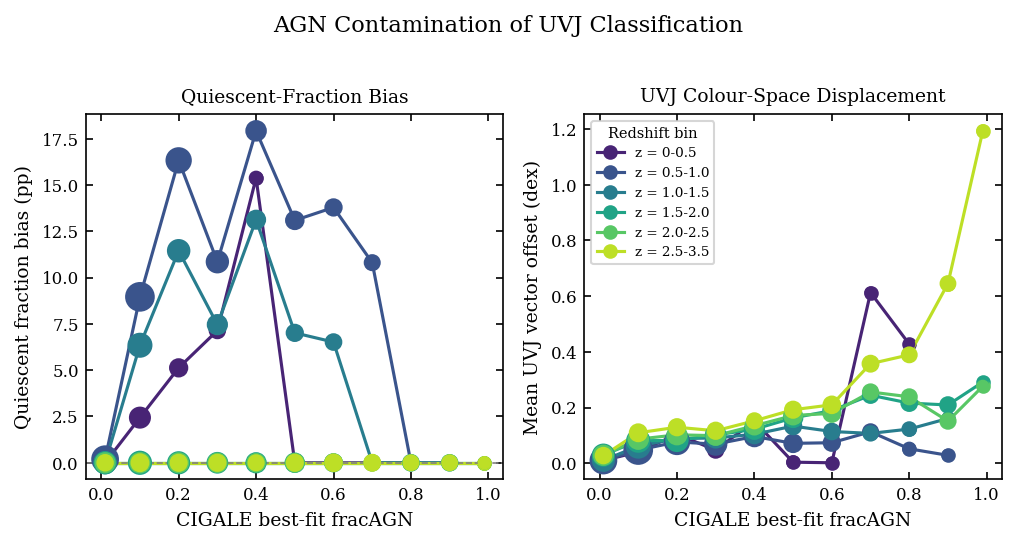

In [3]:
fig, axes = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharex=True)

frac_grid = sorted(contam_df['fracAGN_bin'].astype(float).unique())
z_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(z_bin_order)))

for color, z_bin in zip(z_colors, z_bin_order):
    subset = contam_df[contam_df['z_bin'] == z_bin].copy()
    subset['fracAGN_val'] = subset['fracAGN_bin'].astype(float)
    subset = subset.set_index('fracAGN_val').reindex(frac_grid).reset_index()
    sizes = 15 + 6 * np.sqrt(subset['N'].clip(lower=0))

    axes[0].plot(subset['fracAGN_val'], subset['Q_bias_pp'], color=color, marker='o', label=f'z = {z_bin}')
    axes[0].scatter(subset['fracAGN_val'], subset['Q_bias_pp'], s=sizes, color=color, zorder=3)

    axes[1].plot(subset['fracAGN_val'], subset['Vector_offset_mag'], color=color, marker='o', label=f'z = {z_bin}')
    axes[1].scatter(subset['fracAGN_val'], subset['Vector_offset_mag'], s=sizes, color=color, zorder=3)

axes[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('CIGALE best-fit fracAGN')
axes[0].set_ylabel('Quiescent fraction bias (pp)')
axes[0].set_title('Quiescent-Fraction Bias')

axes[1].set_xlabel('CIGALE best-fit fracAGN')
axes[1].set_ylabel('Mean UVJ vector offset (dex)')
axes[1].set_title('UVJ Colour-Space Displacement')
axes[1].legend(title='Redshift bin', fontsize=6.5, title_fontsize=7, loc='best')

fig.suptitle('AGN Contamination of UVJ Classification', y=1.02)
fig.tight_layout()

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Contamination_Bias_Summary.pdf'), bbox_inches='tight')
plt.show()

## 3. Headline Numbers

Quick reference for the paper text: the worst-case bias and displacement, and the redshift / AGN-fraction regime in which each occurs.

In [4]:
max_bias_row = contam_df.loc[contam_df['Q_bias_pp'].idxmax()]
max_offset_row = contam_df.loc[contam_df['Vector_offset_mag'].idxmax()]

print('Maximum quiescent-fraction bias:')
print(f"  {max_bias_row['Q_bias_pp']:.1f} pp at z = {max_bias_row['z_bin']}, fracAGN = {max_bias_row['fracAGN_bin']} (N = {int(max_bias_row['N'])})\n")

print('Maximum mean UVJ vector offset:')
print(f"  {max_offset_row['Vector_offset_mag']:.3f} dex at z = {max_offset_row['z_bin']}, fracAGN = {max_offset_row['fracAGN_bin']} (N = {int(max_offset_row['N'])})")

Maximum quiescent-fraction bias:
  17.9 pp at z = 0.5-1.0, fracAGN = 0.4 (N = 145)

Maximum mean UVJ vector offset:
  1.194 dex at z = 2.5-3.5, fracAGN = 0.99 (N = 6)
